# End to End Pipeline

## Making the fit

To make the eccentricity fit, Pyrex uses the following equation to compute the eccentricity contribution to both the phase and amplitude
$$e_X = \frac{X_{\text{NR}}(X_c)-X_c}{2X_c},$$
with $X$ being both $\omega$, the instantaneous frequency and $\mathcal{A}$, the amplitude. $X_c$ means that these quantities were taken from a circular simulation and $X_\text{NR}$ means that they were taken from an eccentric simulation.

The resulting $e_X$ equations are then fit according to the following relation
$$e_X = Ae^{BX^\kappa_c}\sin(fX^\kappa_c + \varphi),$$
with $A, B, f$ and $\varphi$ standard damped sinusoidal parameters. It turns out that $A$ and $B$ are highly correlated with the eccentricity, $f^2$ with the mass ratio, and $\varphi$ an extra degree of freedom of which the behaviour is not well understood. $\kappa$ takes different values for the instantaneouos frequency and amplitude, namely $\kappa = -59/24$ for the frequency and $\kappa=-83/24$ for the amplitude for a circular BBH with a total mass $M=50M_\odot$.

### How it works

In practice, $X_c$ are the components of a simulation with the same mass ratio and zero eccentricity. In other words, for every mass ratio in the used eccentric simulations there needs to be a circular simulation with the same mass ratio. $X_\text{NR}$ are then the components of an eccentric binary simulation. However, this method only works if the only major differences in these simulations is the eccentricity and mass ratio. The mean anomaly is *not* used.

In [7]:
import matplotlib.pyplot as plt
from pyrex.eccentric_extension import generate_eccentric_waveform
from pyrex.eccentric_fit import fit_waveform_eccentricity
from qcextender.waveform import Waveform

In [8]:
sims = ["SXS:BBH:0180v2.0", "SXS:BBH:1355", "SXS:BBH:1357", "SXS:BBH:1362", "SXS:BBH:1363v2.0", "SXS:BBH:0184v2.0", "SXS:BBH:1364", "SXS:BBH:1368", "SXS:BBH:1369", "SXS:BBH:0183v2.0", "SXS:BBH:1373", "SXS:BBH:1374"]

training = fit_waveform_eccentricity(names=sims, outfname="sample_data/pyrexdata.pkl")

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/sxs/simulations/simulation.py:203: UserWarning: 
Simulation 'SXS:BBH:0184' is deprecated, but you explicitly
requested version 'v2.0', so it is being used.
Pass `ignore_deprecation=True` to quiet this warning.

  warn(message)
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/sxs/simulations/simulation.py:203: UserWarning: 
Simulation 'SXS:BBH:0183' is deprecated, but you explicitly
requested version 'v2.0', so it is being used.
Pass `ignore_deprecation=True` to quiet this warning.

  warn(message)


### Single waveform visual check

Listed here are two visual comparisons of the strain, accumulated phase, and amplitude. These offer only a small insight and are only listed to show the validity of the following mismatch calculations. Notable here is the cut made by Pyrex at $-1500M$. 

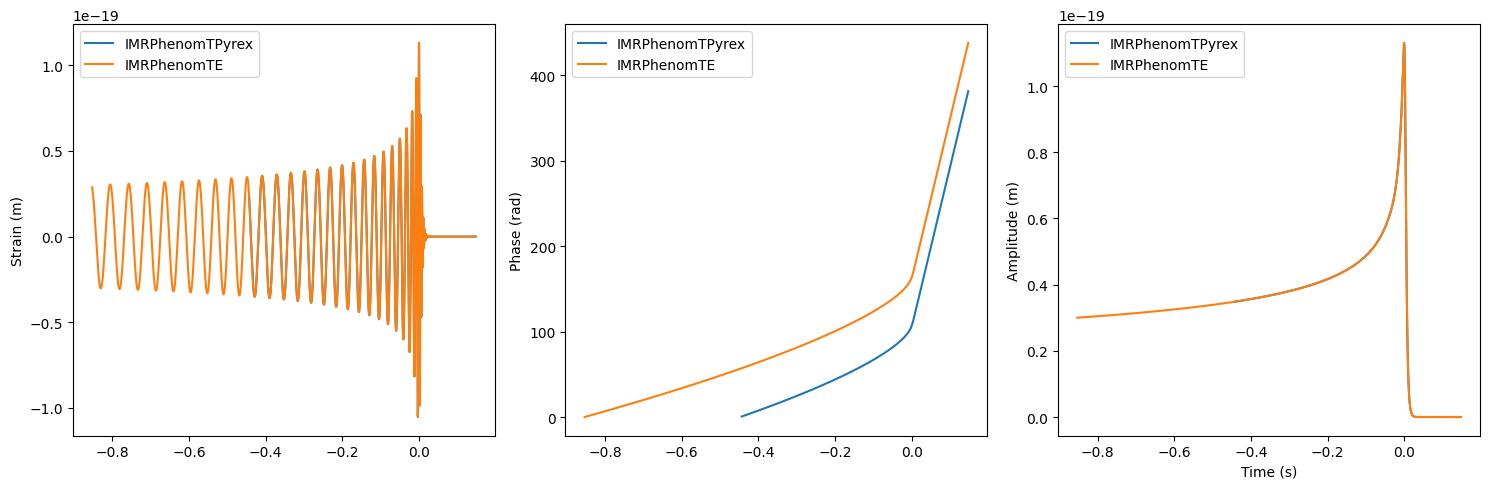

In [9]:
kwargs = {
    "approximant": "IMRPhenomTE",
    "mass1": 30,
    "mass2": 30,
    "inclination": 0,
    "coa_phase": 0,
    "delta_t": 1.0 / 4196,
    "f_lower": 20,
    "f_ref": 25,
    "distance": 10,
}

phen = Waveform.from_model(**kwargs)
kwargs.update({"eccentricity": 0,})
phen_ecc = generate_eccentric_waveform(dirfile="sample_data/pyrexdata.pkl", **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phen_ecc.time, phen_ecc[2, 2], label="IMRPhenomTPyrex")
axes[0].plot(phen.time, phen[2, 2], label="IMRPhenomTE")
axes[0].set_ylabel("Strain (m)")
axes[0].legend()

axes[1].plot(phen_ecc.time, phen_ecc.phase(), label="IMRPhenomTPyrex")
axes[1].plot(phen.time, phen.phase(), label="IMRPhenomTE")
axes[1].set_ylabel("Phase (rad)")
axes[1].legend()

axes[2].plot(phen_ecc.time, phen_ecc.amp(), label="IMRPhenomTPyrex")
axes[2].plot(phen.time, phen.amp(), label="IMRPhenomTE")
axes[2].set_ylabel("Amplitude (m)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Inspecting individual waveforms

The eccentricity caused modulations to the amplitude and frequency are stored in a file with a datapoint at the points in parameter space covered by the simulations. For every waveform generated by Pyrex these points are taken and then interpolated according to the correlations mentioned above.

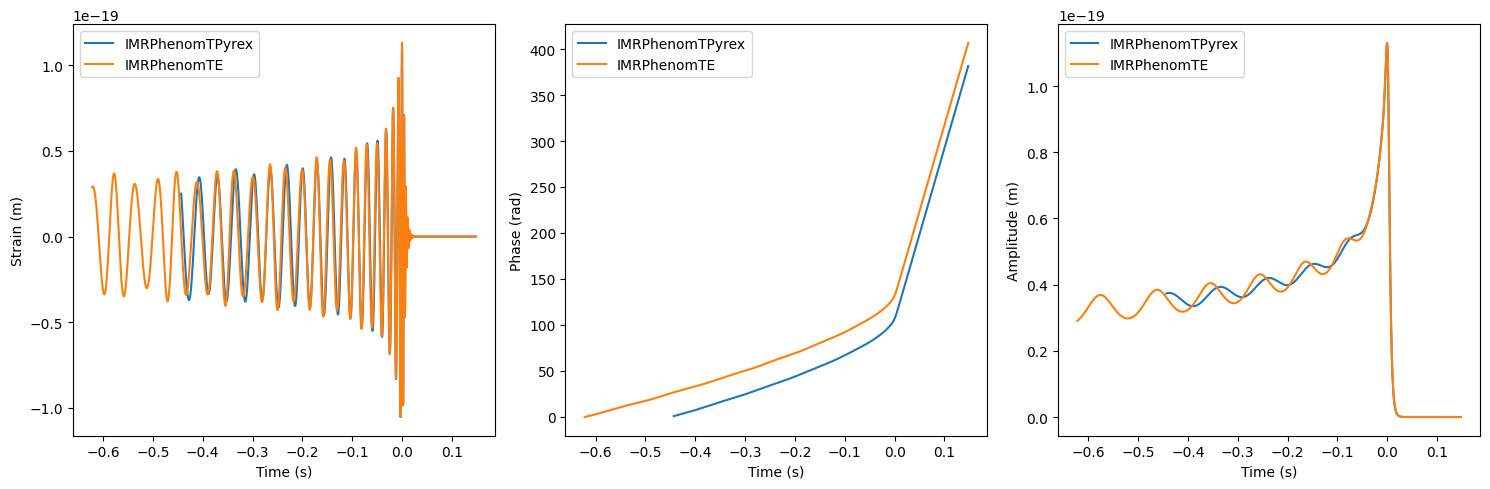

In [10]:
kwargs = {
    "approximant": "IMRPhenomTE",
    "mass1": 30,
    "mass2": 30,
    "inclination": 0,
    "coa_phase": 0,
    "delta_t": 1.0 / 4196,
    "f_lower": 20,
    "f_ref": 25,
    "distance": 10,
    "eccentricity": 0.1
}

phen = Waveform.from_model(**kwargs)
phen_ecc = generate_eccentric_waveform(dirfile="sample_data/pyrexdata.pkl", **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phen_ecc.time, phen_ecc[2, 2], label="IMRPhenomTPyrex")
axes[0].plot(phen.time, phen[2, 2], label="IMRPhenomTE")
axes[0].set_ylabel("Strain (m)")
axes[0].set_xlabel("Time (s)")
axes[0].legend()

axes[1].plot(phen_ecc.time, phen_ecc.phase(), label="IMRPhenomTPyrex")
axes[1].plot(phen.time, phen.phase(), label="IMRPhenomTE")
axes[1].set_ylabel("Phase (rad)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

axes[2].plot(phen_ecc.time, phen_ecc.amp(), label="IMRPhenomTPyrex")
axes[2].plot(phen.time, phen.amp(), label="IMRPhenomTE")
axes[2].set_ylabel("Amplitude (m)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

plt.tight_layout()
plt.show()